# 10 DGE Visualization and Exploration

## Overview
This notebook provides reusable visualization and exploration utilities for differential expression results generated in notebook 09. It reads saved DGE workbooks rather than recomputing DGE, so downstream review remains fast and reproducible.

## Purpose
- Load saved DGE tables by annotation level and cell type
- Generate reusable volcano, top-gene, rank-curve, and p-value distribution plots
- Support selective or batched figure generation without rerunning notebook 09

## Upstream Dependencies
- `Results/DGE/DGE_level_class_nb09.xlsx`
- `Results/DGE/DGE_level_subclass_nb09.xlsx`
- `Results/DGE/DGE_level_supertype_nb09.xlsx`
- `Results/DGE/DGE_level_cluster_nb09.xlsx`

## Primary Outputs
- `Results/DGE/plots/level_<level>/<cell_type>__volcano.png`
- `Results/DGE/plots/level_<level>/<cell_type>__top_genes.png`
- `Results/DGE/plots/level_<level>/<cell_type>__rank_curve.png`
- `Results/DGE/plots/level_<level>/<cell_type>__pvalue_hist.png`
- `Results/DGE/plots/plot_run_manifest_nb10.csv`

## Scope Boundary
- DGE generation ownership: notebook `09`
- This notebook owns visualization and exploratory review of saved DGE outputs
- GSEA from saved DGE ownership: notebook `11`

## Standards
- Treat saved DGE workbooks as the source of truth for plotting
- Keep visualization functions reusable and side-effect light
- Put ad hoc exploration and example runs in the final analysis section only

# Table of Contents

1. [Overview](#overview)
2. [Purpose](#purpose)
3. [Upstream Dependencies](#upstream-dependencies)
4. [Primary Outputs](#primary-outputs)
5. [Scope Boundary](#scope-boundary)
6. [Standards](#standards)
7. [Setup and Utility Functions](#setup-and-utility-functions)
8. [Plot Functions and Controller](#plot-functions-and-controller)
9. [Analysis](#analysis)

## Setup and Utility Functions

Load configuration, workbook path helpers, sheet-resolution logic, and lightweight readers for saved DGE outputs.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from time import perf_counter
from typing import Final, Sequence

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


@dataclass(frozen=True)
class Notebook10VizConfig:
    """Centralized filesystem configuration and plot thresholds for notebook 10."""

    analysis_root: Path
    dge_dir: Path
    plot_dir: Path
    padj_threshold: float
    abs_logfc_threshold: float


ANALYSIS_ROOT: Final[Path] = Path("/media/drive_c/Project_Brain_snRNAseq/Analysis")
CONFIG = Notebook10VizConfig(
    analysis_root=ANALYSIS_ROOT,
    dge_dir=ANALYSIS_ROOT / "Results" / "DGE",
    plot_dir=ANALYSIS_ROOT / "Results" / "DGE" / "plots",
    padj_threshold=0.05,
    abs_logfc_threshold=0.25,
)
CONFIG.plot_dir.mkdir(parents=True, exist_ok=True)

# Small in-memory caches avoid repeatedly parsing large Excel workbooks.
_XLS_CACHE: dict[str, pd.ExcelFile] = {}
_CELLTYPE_LIST_CACHE: dict[str, list[str]] = {}


def sanitize_name(text: str) -> str:
    """Return a filesystem-safe label for plot filenames and directories."""
    text_str = str(text)
    keep: list[str] = [char if char.isalnum() or char in ("-", "_") else "_" for char in text_str]
    return "".join(keep).strip("_")[:120]


def dge_workbook_candidates(level: str, cfg: Notebook10VizConfig = CONFIG) -> list[Path]:
    """Return candidate workbook paths ordered by current then legacy naming."""
    return [
        cfg.dge_dir / f"DGE_level_{level}_nb09.xlsx",
        cfg.dge_dir / f"DGE_level_{level}.xlsx",
    ]


def resolve_existing_workbook_path(level: str, cfg: Notebook10VizConfig = CONFIG) -> Path:
    """Resolve the first existing workbook path for the requested annotation level."""
    candidates = dge_workbook_candidates(level=level, cfg=cfg)
    for candidate in candidates:
        if candidate.exists():
            return candidate

    formatted = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        f"Missing DGE workbook for level={level}. Tried:\n{formatted}"
    )


def get_excel_file(level: str, cfg: Notebook10VizConfig = CONFIG) -> pd.ExcelFile:
    """Return a cached ExcelFile handle for the requested DGE workbook.

    Args:
        level: Annotation level such as `class` or `subclass`.
        cfg: Notebook configuration containing the DGE directory.

    Returns:
        Cached `pandas.ExcelFile` handle.

    Raises:
        FileNotFoundError: When no expected workbook path exists.
    """
    key = str(level)
    if key in _XLS_CACHE:
        return _XLS_CACHE[key]

    path = resolve_existing_workbook_path(level=level, cfg=cfg)
    xls = pd.ExcelFile(path)
    _XLS_CACHE[key] = xls
    return xls


def resolve_sheet_name(level: str, cell_type: str, cfg: Notebook10VizConfig = CONFIG) -> str:
    """Map a canonical cell-type label to the corresponding Excel sheet name.

    This handles Excel sheet truncation and basic normalization differences.

    Args:
        level: Annotation level workbook to inspect.
        cell_type: Canonical cell-type label requested by the user.
        cfg: Notebook configuration containing workbook locations.

    Returns:
        Exact sheet name present in the workbook.

    Raises:
        ValueError: When the cell type cannot be mapped to a unique sheet.
    """
    xls = get_excel_file(level, cfg=cfg)
    sheets: list[str] = [str(sheet) for sheet in xls.sheet_names]
    if cell_type in sheets:
        return cell_type

    candidate = str(cell_type).replace("/", "_")[:31]
    if candidate in sheets:
        return candidate

    lowered = {sheet.lower(): sheet for sheet in sheets}
    if candidate.lower() in lowered:
        return lowered[candidate.lower()]

    matches = [
        sheet for sheet in sheets
        if candidate.lower() in sheet.lower() or sheet.lower() in candidate.lower()
    ]
    if len(matches) == 1:
        return matches[0]

    raise ValueError(f"Could not map cell_type '{cell_type}' to a workbook sheet at level={level}")


def read_dge_sheet(level: str, cell_type: str, cfg: Notebook10VizConfig = CONFIG) -> pd.DataFrame:
    """Read one cell-type DGE sheet from the saved workbook.

    Args:
        level: Annotation level workbook to query.
        cell_type: Cell-type label to load.
        cfg: Notebook configuration containing workbook locations.

    Returns:
        DGE dataframe for the requested sheet.
    """
    xls = get_excel_file(level, cfg=cfg)
    sheet = resolve_sheet_name(level, cell_type, cfg=cfg)
    df = pd.read_excel(xls, sheet_name=sheet)

    if "cell_type" not in df.columns:
        df["cell_type"] = cell_type
    df["cell_type"] = df["cell_type"].astype(str)
    return df


def available_cell_types(level: str, cfg: Notebook10VizConfig = CONFIG) -> list[str]:
    """Return the available cell-type sheet names for one annotation level."""
    key = str(level)
    if key in _CELLTYPE_LIST_CACHE:
        return _CELLTYPE_LIST_CACHE[key]

    xls = get_excel_file(level, cfg=cfg)
    cell_types = sorted(str(sheet) for sheet in xls.sheet_names)
    _CELLTYPE_LIST_CACHE[key] = cell_types
    return cell_types


def subset_dge(level: str, cell_type: str, cfg: Notebook10VizConfig = CONFIG) -> pd.DataFrame:
    """Load and normalize one cell-type DGE table for plotting.

    Args:
        level: Annotation level workbook to query.
        cell_type: Cell-type label to load.
        cfg: Notebook configuration containing workbook locations and thresholds.

    Returns:
        Plot-ready DGE dataframe with derived significance columns.

    Raises:
        ValueError: When the target sheet is empty.
        KeyError: When required DGE columns are missing.
    """
    start_time = perf_counter()
    df = read_dge_sheet(level=level, cell_type=cell_type, cfg=cfg)
    if df.empty:
        raise ValueError(f"DGE sheet is empty for level={level}, cell_type={cell_type}")

    required_cols = {"gene", "logFC", "p_val"}
    missing = sorted(required_cols - set(df.columns))
    if missing:
        raise KeyError(f"Missing required DGE columns: {missing}")

    if "cell_type" in df.columns:
        df = df[df["cell_type"].astype(str) == str(cell_type)].copy()
    else:
        df = df.copy()
    if df.empty:
        df = read_dge_sheet(level=level, cell_type=cell_type, cfg=cfg).copy()

    pcol = "p_adj" if "p_adj" in df.columns else "p_val"
    df["p_plot"] = pd.to_numeric(df[pcol], errors="coerce").fillna(1.0).clip(lower=np.finfo(float).tiny)
    df["logFC"] = pd.to_numeric(df["logFC"], errors="coerce")
    df["neg_log10_p"] = -np.log10(df["p_plot"])
    out = df.dropna(subset=["gene", "logFC", "neg_log10_p"]).copy()
    elapsed = perf_counter() - start_time
    print(f"Loaded DGE for level={level}, cell_type={cell_type} in {elapsed:.2f}s (rows={len(out)})")
    return out

## Plot Functions and Controller

Define reusable visualization functions and the controller used for selective plot generation from saved DGE tables. This section should remain library-only; example runs belong in the final analysis section.

In [2]:
def mark_significance(
    df: pd.DataFrame,
    padj_threshold: float = CONFIG.padj_threshold,
    abs_logfc_threshold: float = CONFIG.abs_logfc_threshold,
    top_effect_n: int = 150,
) -> pd.DataFrame:
    """Annotate a DGE dataframe with significance and fallback effect-score labels.

    Args:
        df: Plot-ready DGE dataframe.
        padj_threshold: Significance threshold applied to `p_adj` or `p_plot`.
        abs_logfc_threshold: Minimum absolute log fold change for significance.
        top_effect_n: Number of fallback high-effect genes to retain when none pass thresholds.

    Returns:
        Copy of the dataframe with plotting classification columns added.
    """
    out = df.copy()
    pcol = "p_adj" if "p_adj" in out.columns else "p_plot"
    out["sig_p"] = pd.to_numeric(out[pcol], errors="coerce").fillna(1.0).clip(lower=np.finfo(float).tiny)
    sig_mask = (out["sig_p"] <= padj_threshold) & (out["logFC"].abs() >= abs_logfc_threshold)
    out["is_sig"] = sig_mask
    out["direction"] = np.where(out["logFC"] >= 0, "up", "down")

    out["effect_score"] = out["logFC"].abs() * out["neg_log10_p"]
    out["is_top_effect"] = False
    if (~out["is_sig"]).all() and len(out) > 0:
        top_index = out["effect_score"].nlargest(min(top_effect_n, len(out))).index
        out.loc[top_index, "is_top_effect"] = True
    return out


def plot_volcano(df: pd.DataFrame, title: str, output_path: Path, show: bool = True) -> Path:
    """Render and save a volcano plot for one cell-type DGE table."""
    fig, ax = plt.subplots(figsize=(9, 7))

    plot_df = df.copy()
    plot_df["volcano_class"] = np.where(
        plot_df["is_sig"],
        "significant",
        np.where(plot_df["is_top_effect"], "top_effect", "background"),
    )
    palette = {
        "background": "#b3b3b3",
        "top_effect": "#4c78a8",
        "significant": "#c1272d",
    }
    sns.scatterplot(
        data=plot_df,
        x="logFC",
        y="neg_log10_p",
        hue="volcano_class",
        palette=palette,
        s=16,
        alpha=0.85,
        linewidth=0,
        ax=ax,
    )
    ax.axvline(CONFIG.abs_logfc_threshold, ls="--", c="#444444", lw=1)
    ax.axvline(-CONFIG.abs_logfc_threshold, ls="--", c="#444444", lw=1)
    ax.axhline(-np.log10(CONFIG.padj_threshold), ls="--", c="#444444", lw=1)
    ax.set_title(title)
    ax.set_xlabel("logFC")
    ax.set_ylabel("-log10(p)")
    ax.legend(title="class", loc="upper right")

    label_df = plot_df[plot_df["is_sig"]].sort_values("neg_log10_p", ascending=False).head(10)
    if label_df.empty:
        label_df = plot_df[plot_df["is_top_effect"]].sort_values("effect_score", ascending=False).head(10)
    for _, row in label_df.iterrows():
        ax.text(row["logFC"], row["neg_log10_p"], str(row["gene"]), fontsize=8, alpha=0.8)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return output_path


def plot_top_genes_bar(
    df: pd.DataFrame,
    title: str,
    output_path: Path,
    top_n: int = 15,
    show: bool = True,
) -> Path:
    """Render and save a bar chart of the strongest up- and down-regulated genes."""
    up = df[df["direction"] == "up"].sort_values("logFC", ascending=False).head(top_n)
    down = df[df["direction"] == "down"].sort_values("logFC", ascending=True).head(top_n)
    plot_df = pd.concat([up, down], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.4)))
    if plot_df.empty:
        ax.text(0.5, 0.5, "No genes to display", ha="center", va="center")
        ax.axis("off")
    else:
        plot_df = plot_df.sort_values("logFC")
        sns.barplot(
            data=plot_df,
            y="gene",
            x="logFC",
            hue="direction",
            palette={"up": "#d1495b", "down": "#00798c"},
            dodge=False,
            ax=ax,
        )
        ax.axvline(0, color="#444444", lw=1)
        ax.set_xlabel("logFC")
        ax.set_ylabel("gene")
        ax.legend(loc="lower right")
    ax.set_title(title)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return output_path


def plot_rank_curve(df: pd.DataFrame, title: str, output_path: Path, show: bool = True) -> Path:
    """Render and save a rank curve across sorted gene log fold changes."""
    rank_df = df.copy().sort_values("logFC", ascending=False).reset_index(drop=True)
    rank_df["rank"] = np.arange(1, len(rank_df) + 1)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.lineplot(data=rank_df, x="rank", y="logFC", color="#2f4b7c", lw=1.2, ax=ax)
    ax.axhline(0, color="#444444", lw=1, ls="--")
    ax.set_title(title)
    ax.set_xlabel("gene rank")
    ax.set_ylabel("logFC")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return output_path


def plot_pvalue_histogram(df: pd.DataFrame, title: str, output_path: Path, show: bool = True) -> Path:
    """Render and save a histogram of p-values or adjusted p-values for one DGE table."""
    fig, ax = plt.subplots(figsize=(8.5, 5))
    plot_values = pd.to_numeric(df["p_plot"], errors="coerce").dropna()
    sns.histplot(x=plot_values, bins=40, color="#4c78a8", edgecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("p-value (or adjusted p-value if provided)")
    ax.set_ylabel("gene count")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return output_path


def append_plot_manifest(manifest_df: pd.DataFrame, manifest_path: Path) -> None:
    """Append one plot-controller run to the cumulative manifest CSV."""
    if manifest_path.exists():
        previous = pd.read_csv(manifest_path)
        pd.concat([previous, manifest_df], ignore_index=True).to_csv(manifest_path, index=False)
    else:
        manifest_df.to_csv(manifest_path, index=False)


def run_dge_plot_controller(
    level: str,
    cell_type: str,
    plots: Sequence[str] = ("volcano", "top_genes", "rank_curve", "pvalue_hist"),
    top_n: int = 15,
    overwrite: bool = False,
    show: bool = True,
    cfg: Notebook10VizConfig = CONFIG,
) -> pd.DataFrame:
    """Generate one or more DGE review plots and record the run in the manifest.

    Args:
        level: Annotation level workbook to query.
        cell_type: Cell-type sheet to visualize.
        plots: Plot kinds to generate.
        top_n: Number of genes per direction for the top-gene bar chart.
        overwrite: If True, regenerate figures even when files already exist.
        show: If True, display figures inline in the notebook.
        cfg: Notebook configuration containing plot directories and thresholds.

    Returns:
        Manifest dataframe for the requested controller run.
    """
    base_df = subset_dge(level=level, cell_type=cell_type, cfg=cfg)
    plot_df = mark_significance(base_df)

    safe_cell = sanitize_name(cell_type)
    level_dir = cfg.plot_dir / f"level_{sanitize_name(level)}"

    plot_map = {
        "volcano": (plot_volcano, f"{safe_cell}__volcano.png"),
        "top_genes": (plot_top_genes_bar, f"{safe_cell}__top_genes.png"),
        "rank_curve": (plot_rank_curve, f"{safe_cell}__rank_curve.png"),
        "pvalue_hist": (plot_pvalue_histogram, f"{safe_cell}__pvalue_hist.png"),
    }

    records: list[dict[str, str]] = []
    for plot_kind in plots:
        if plot_kind not in plot_map:
            records.append({"plot": plot_kind, "status": "unknown_plot", "path": ""})
            continue

        func, filename = plot_map[plot_kind]
        out_path = level_dir / filename
        if out_path.exists() and not overwrite:
            records.append({"plot": plot_kind, "status": "skipped_exists", "path": str(out_path)})
            continue

        title = f"DGE {plot_kind.replace('_', ' ').title()} | level={level} | cell={cell_type}"
        if plot_kind == "top_genes":
            func(plot_df, title=title, output_path=out_path, top_n=top_n, show=show)
        else:
            func(plot_df, title=title, output_path=out_path, show=show)
        records.append({"plot": plot_kind, "status": "generated", "path": str(out_path)})

    manifest_df = pd.DataFrame.from_records(records)
    manifest_df.insert(0, "timestamp", datetime.now().isoformat(timespec="seconds"))
    manifest_df.insert(1, "level", level)
    manifest_df.insert(2, "cell_type", cell_type)

    manifest_path = cfg.plot_dir / "plot_run_manifest_nb10.csv"
    append_plot_manifest(manifest_df, manifest_path)
    return manifest_df

## Analysis

Interactive workspace. All reusable plotting and loading functions live in the cells above; modify or rerun cells here freely without touching the library code.

`available_cell_types(level)` lists workbook-backed cell types for a chosen annotation level.
`run_dge_plot_controller(level, cell_type, plots, ...)` generates one or more saved review plots and appends a manifest entry.

In [3]:
# Analysis example: pick one workbook-backed cell type and inspect it.
LEVEL = "subclass"
all_cells = available_cell_types(LEVEL)
lsx_gaba_cells = [cell_type for cell_type in all_cells if "LSX" in cell_type and "GABA" in cell_type]
if lsx_gaba_cells:
    SELECTED_CELL = lsx_gaba_cells[0]
else:
    gaba_cells = [cell_type for cell_type in all_cells if "GABA" in cell_type]
    SELECTED_CELL = gaba_cells[0] if gaba_cells else all_cells[0]

print(f"Level: {LEVEL}")
print(f"Total available cell types: {len(all_cells)}")
print(f"Selected analysis cell type: {SELECTED_CELL}")
if lsx_gaba_cells:
    print(f"Other LSX GABA options: {lsx_gaba_cells}")

Level: subclass
Total available cell types: 213
Selected analysis cell type: 001 CLA-EPd-CTX Car3 Glut


Loaded DGE for level=subclass, cell_type=001 CLA-EPd-CTX Car3 Glut in 2.03s (rows=16033)


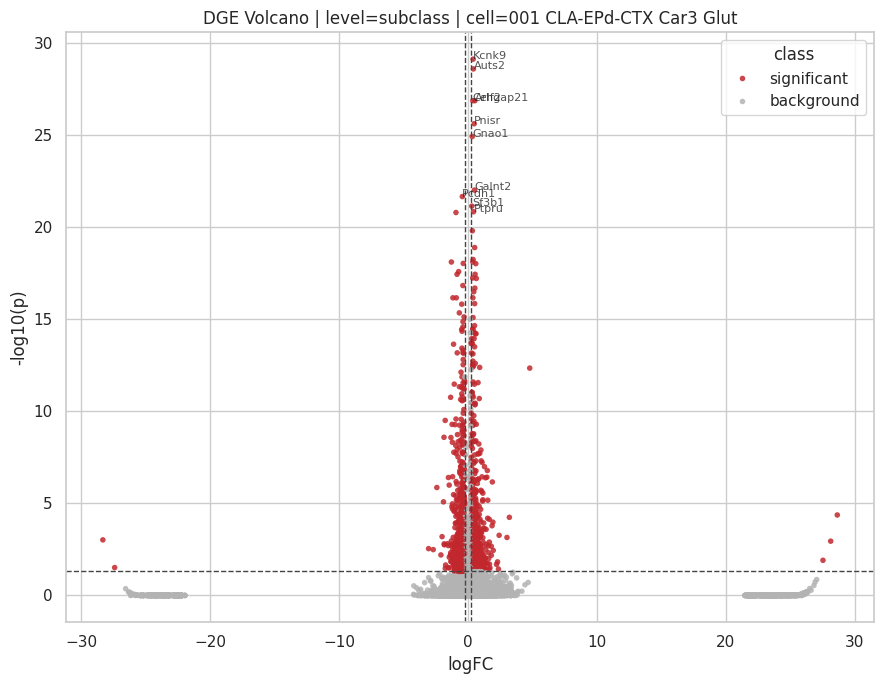

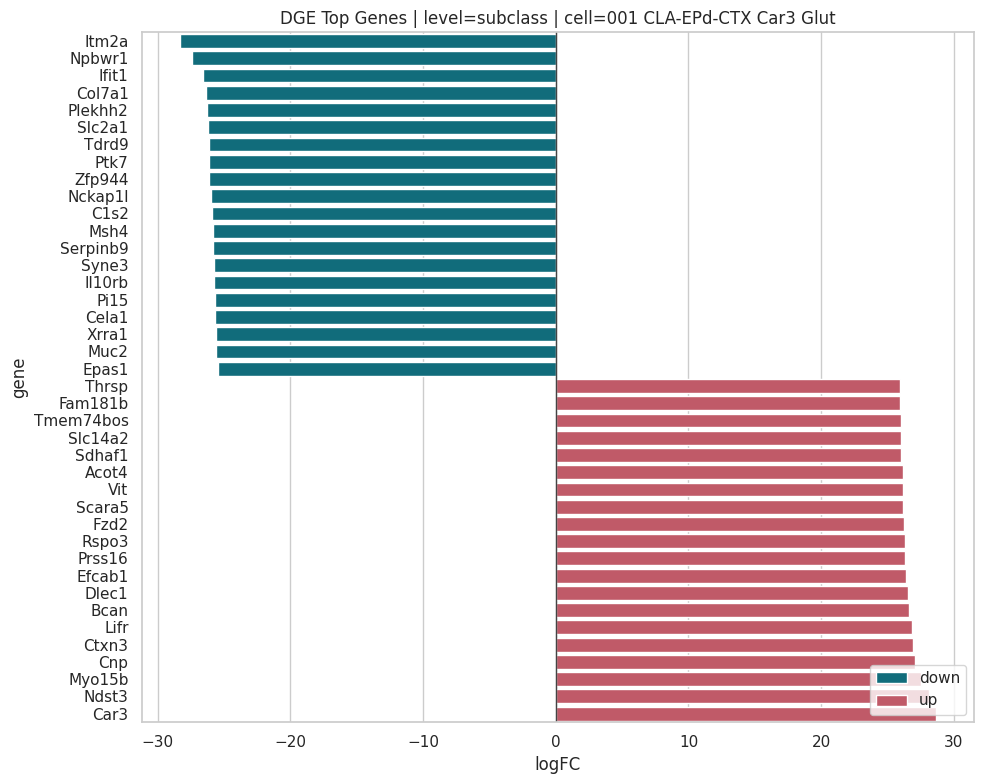

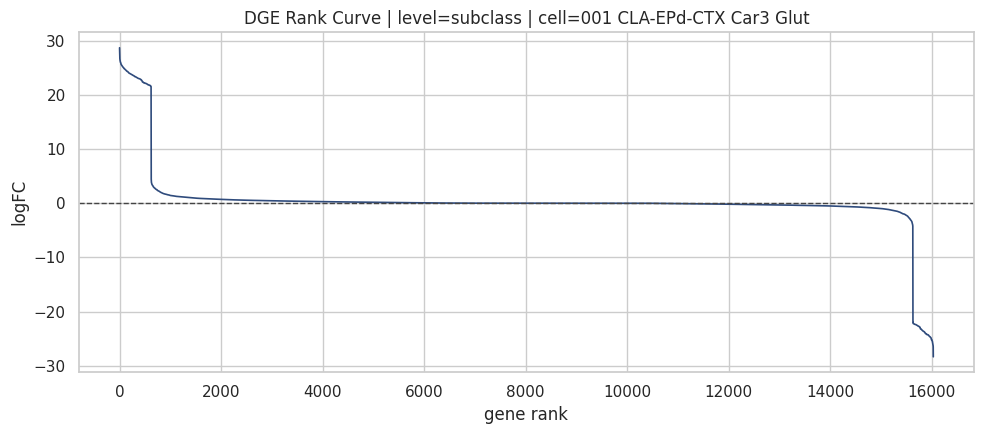

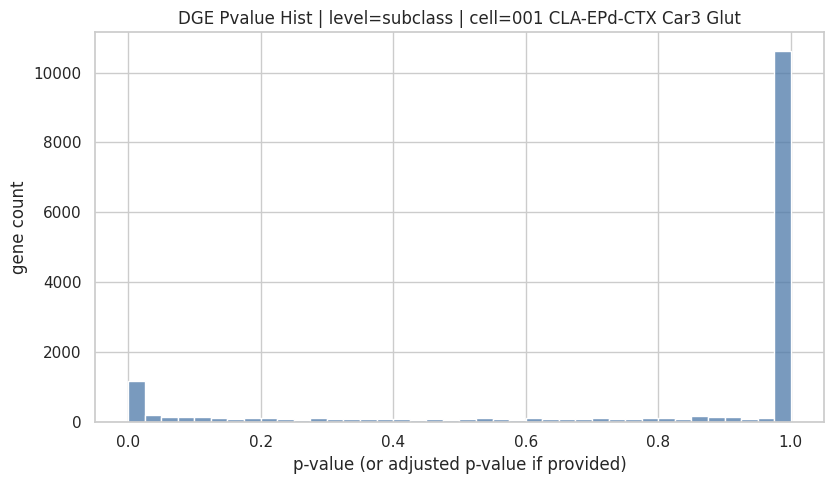

,timestamp,level,cell_type,plot,status,path
0,2026-05-05T10:48:02,subclass,001 CLA-EPd-CTX Car3 Glut,volcano,generated,/media/drive_c/Project_Brain_snRNAseq/Analysis...
1,2026-05-05T10:48:02,subclass,001 CLA-EPd-CTX Car3 Glut,top_genes,generated,/media/drive_c/Project_Brain_snRNAseq/Analysis...
2,2026-05-05T10:48:02,subclass,001 CLA-EPd-CTX Car3 Glut,rank_curve,generated,/media/drive_c/Project_Brain_snRNAseq/Analysis...
3,2026-05-05T10:48:02,subclass,001 CLA-EPd-CTX Car3 Glut,pvalue_hist,generated,/media/drive_c/Project_Brain_snRNAseq/Analysis...


In [4]:
demo_manifest = run_dge_plot_controller(
    level=LEVEL,
    cell_type=SELECTED_CELL,
    plots=("volcano", "top_genes", "rank_curve", "pvalue_hist"),
    top_n=20,
    overwrite=True,
    show=True,
)
display(demo_manifest)